In [1]:
# step 1 -: import important libraries

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

In [2]:
# step 2 -: load the data set 
df = pd.read_csv("C:/Users/swapn/Machine_Learning/Train/Dataset/data.csv")
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [4]:
# step 3 (EDA -: Exploratery data analysis)
df.shape

(4600, 18)

In [5]:
# checking missing values 
df.isnull().sum().sort_values(ascending = False).head(15)

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
dtype: int64

In [7]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='object')

In [8]:
df.dtypes

date              object
price            float64
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
street            object
city              object
statezip          object
country           object
dtype: object

In [9]:
# check correlation 
corr = df.corr(numeric_only = True)
corr['price'].sort_values(ascending=False)

price            1.000000
sqft_living      0.430410
sqft_above       0.367570
bathrooms        0.327110
view             0.228504
sqft_basement    0.210427
bedrooms         0.200336
floors           0.151461
waterfront       0.135648
sqft_lot         0.050451
condition        0.034915
yr_built         0.021857
yr_renovated    -0.028774
Name: price, dtype: float64

In [10]:
# step 4 -: sample model 

X = df[['sqft_living','sqft_above','bathrooms','view','sqft_basement','bedrooms','floors','waterfront','sqft_lot','condition','yr_built','yr_renovated']]
y = df['price']

In [11]:
# step 5 -: train_test_split 

X_train , X_test , y_train , y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [12]:
# step 6 -: Fit model (linear regression )

model = LinearRegression()
model.fit(X_train,y_train)

# Check coefficient :
print("Intercept:",model.intercept_)
print("Coefficient : ",model.coef_)

Intercept: 4925638.0661926875
Coefficient :  [ 1.86049845e+02  9.68608171e+01  3.65204407e+04  4.47558418e+04
  8.91890278e+01 -6.44974616e+04  6.98247401e+04  3.82459666e+05
 -5.14414161e-01  2.93355394e+04 -2.56916353e+03  8.25991734e+00]


In [13]:
# Step 7 (Predicition)

y_pred = model.predict(X_test)

In [14]:
# Step 8 (Model Evaluation)

# MSE:
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

# MAE:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

# R² Score:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

MSE: 986921767056.1335
MAE: 210908.1732501161
R2 Score: 0.03228385663276867


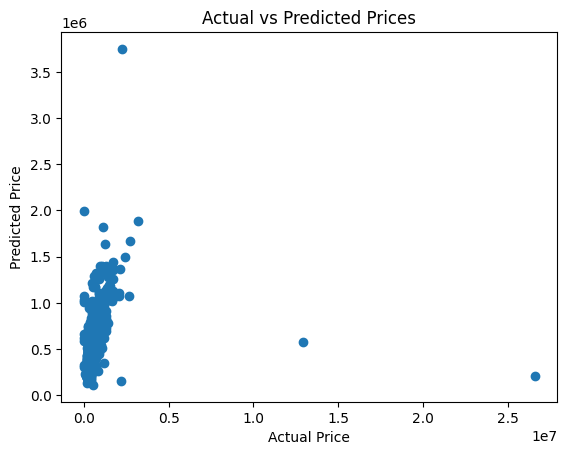

In [15]:
# Step 9 (Visualization Prediction)

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()